# Baseline Machine Learning Models

## Research Goal

*This notebook evaluates the performance of different machine learning algorithms on the Titanic dataset.*
## Models

- Logistic Regression
- Decision Tree
- Random Forest

## Metrics

- Accuracy
- Precision
- Recall
- F1-score

In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (accuracy_score,precision_score, recall_score,f1_score)

from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

# Loading Dataset

In [ ]:
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Dataset Exploration
Before training machine learning models, the dataset structure and quality are analyzed.

In [ ]:
# Check dataset information
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


## Data Preprocessing
Missing values are handled and categorical variables are converted into numerical format.

In [ ]:
df = pd.read_csv("Titanic-Dataset.csv")

df['Age'] = df['Age'].fillna(df['Age'].median())

df['Fare'] = df['Fare'].fillna(df['Fare'].median())

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])



### Encoding Categorical Variables

Categorical features are converted into numerical values using one-hot encoding because machine learning algorithms require numerical input.

In [ ]:
df = pd.get_dummies(df, drop_first=True)

df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,"Name_Abbott, Mr. Rossmore Edward","Name_Abbott, Mrs. Stanton (Rosa Hunt)","Name_Abelson, Mr. Samuel",...,Cabin_F G63,Cabin_F G73,Cabin_F2,Cabin_F33,Cabin_F38,Cabin_F4,Cabin_G6,Cabin_T,Embarked_Q,Embarked_S
0,1,0,3,22.0,1,0,7.2500,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,2,1,1,38.0,1,0,71.2833,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,1,3,26.0,0,0,7.9250,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,4,1,1,35.0,1,0,53.1000,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,5,0,3,35.0,0,0,8.0500,False,False,False,...,False,False,False,False,False,False,False,False,False,True


## Preparing Data for Training

The dataset is divided into features and target variable.

Features contain information about passengers, while the target variable represents the survival outcome.

In [ ]:
X = df.drop("Survived", axis=1)

y = df["Survived"]

## 6. Splitting the Dataset

The dataset is divided into training and testing subsets.

The training set is used to train the machine learning model, while the testing set is used to evaluate its performance on unseen data.

The same train-test split is applied in all experiments to ensure a fair comparison between different machine learning models.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split( X, y,test_size=0.2,random_state=42)


## Logistic Regression

Logistic Regression is used as a baseline classification model.

It estimates the probability of an event occurring based on input features.

In [ ]:
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train, y_train)

y_pred_logistic = logistic_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Logistic Regression Performance

In [ ]:
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
logistic_precision = precision_score(y_test, y_pred_logistic)
logistic_recall = recall_score(y_test, y_pred_logistic)
logistic_f1 = f1_score(y_test, y_pred_logistic)


print("Accuracy:", round(logistic_accuracy, 3))
print("Precision:", round(logistic_precision, 3))
print("Recall:", round(logistic_recall, 3))
print("F1-score:", round(logistic_f1, 3))

Accuracy: 0.816
Precision: 0.797
Recall: 0.743
F1-score: 0.769


## Confusion Matrix

The confusion matrix provides a detailed overview of the model's predictions.

It shows how many passengers were correctly and incorrectly classified.

Unlike Accuracy, the confusion matrix helps identify specific types of errors, such as false positives and false negatives.

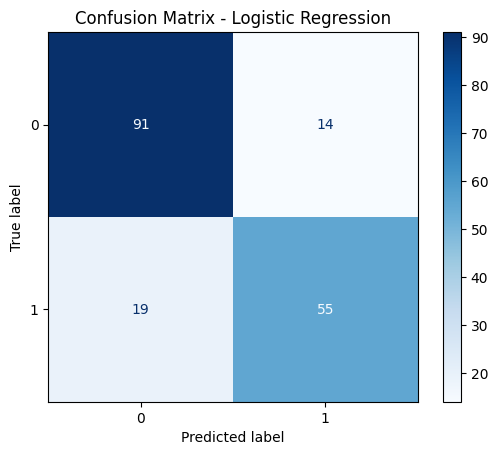

In [ ]:
cm = confusion_matrix(y_test, y_pred_logistic)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## Conclusion

In this experiment, a Logistic Regression model was trained and evaluated using the Titanic dataset.

The model achieved an Accuracy of 0.816 and an F1-score of 0.769, demonstrating its ability to make reliable predictions.

The results from this experiment will be used as a baseline for comparison with other machine learning models, including Decision Tree and Random Forest.